In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('netflix_titles.csv')
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons
...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
dtypes: int64(1), object(9)
memory usage: 688.2+ KB


In [4]:
df.corr()

,release_year
release_year,1.0


#### Check null values

In [5]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
dtype: int64

In [6]:
df.isnull().sum()/len(df)*100

show_id          0.000000
type             0.000000
title            0.000000
director        29.908028
cast             9.367549
country          9.435676
date_added       0.113546
release_year     0.000000
rating           0.045418
duration         0.034064
dtype: float64

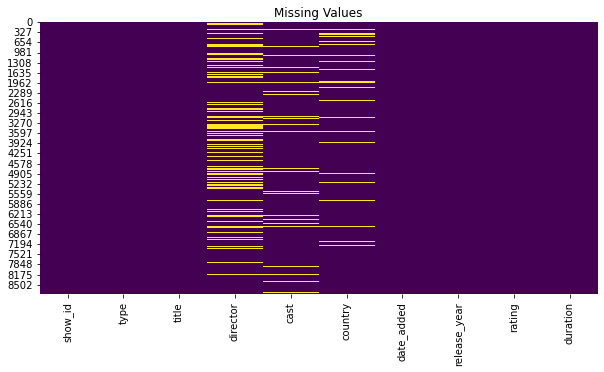

In [7]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')

plt.title("Missing Values")
plt.show()

#### Director

In [8]:
df['director'].fillna("Not Availabel",inplace=True)

#### Cast

In [9]:
df['cast'].fillna("Not Availabel",inplace=True)

#### Country

In [10]:
df['country'].fillna(df['country'].mode()[0],inplace=True)

#### date_added

In [11]:
df['date_added'].fillna("Not availabel",inplace=True)

#### rating

In [12]:
df['rating'].fillna(df['rating'].mode()[0],inplace=True)

#### duration

In [13]:
df['duration'].fillna(df['duration'].mode()[0],inplace=True)

In [14]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
dtype: int64

#### remove extra spaces

In [15]:
df['director'] = df['director'].str.strip()
df['cast'] = df['cast'].str.strip()
df['country'] = df['country'].str.strip()
df['rating'] = df['rating'].str.strip()

In [16]:
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Availabel,United States,"September 25, 2021",2020,PG-13,90 min
1,s2,TV Show,Blood & Water,Not Availabel,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,"September 24, 2021",2021,TV-MA,1 Season
3,s4,TV Show,Jailbirds New Orleans,Not Availabel,Not Availabel,United States,"September 24, 2021",2021,TV-MA,1 Season
4,s5,TV Show,Kota Factory,Not Availabel,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons
...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min
8803,s8804,TV Show,Zombie Dumb,Not Availabel,Not Availabel,United States,"July 1, 2019",2018,TV-Y7,2 Seasons
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min


#### Convert date column

In [17]:
df['date_added'] = pd.to_datetime(df['date_added'],errors='coerce')

In [18]:
df.dtypes

show_id                 object
type                    object
title                   object
director                object
cast                    object
country                 object
date_added      datetime64[ns]
release_year             int64
rating                  object
duration                object
dtype: object

In [19]:
for col in df.columns:
    print(col, df[col].nunique())

show_id 8807
type 2
title 8807
director 4529
cast 7693
country 748
date_added 1714
release_year 74
rating 17
duration 220


In [20]:
df['rating'].unique()

array(['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R',
       'TV-G', 'G', 'NC-17', '74 min', '84 min', '66 min', 'NR',
       'TV-Y7-FV', 'UR'], dtype=object)

#### Check Outliers

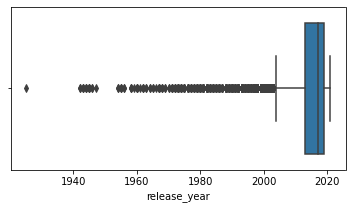

In [21]:
plt.figure(figsize=(6,3))
sns.boxplot(x=df['release_year'])

plt.show()

#### Rename Column

In [22]:
df.rename(columns={
    'show_id':'Show_ID',
    'type':'Type',
    'title':'Title',
    'director': 'Director',               
    'cast': 'Cast' ,                  
    'country':'Country'   ,            
    'date_added':'Date_added'  ,  
    'release_year':'Release_Year',             
    'rating':'Rating' ,                 
    'duration':'Duration'
}, inplace=True)

In [23]:
df

,Show_ID,Type,Title,Director,Cast,Country,Date_added,Release_Year,Rating,Duration
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Availabel,United States,2021-09-25,2020,PG-13,90 min
1,s2,TV Show,Blood & Water,Not Availabel,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021-09-24,2021,TV-MA,1 Season
3,s4,TV Show,Jailbirds New Orleans,Not Availabel,Not Availabel,United States,2021-09-24,2021,TV-MA,1 Season
4,s5,TV Show,Kota Factory,Not Availabel,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons
...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 min
8803,s8804,TV Show,Zombie Dumb,Not Availabel,Not Availabel,United States,2019-07-01,2018,TV-Y7,2 Seasons
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min


#### Check duplicates

In [24]:
df.duplicated().sum()

0

In [25]:
df['Show_ID'].duplicated().sum()

0

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Show_ID       8807 non-null   object        
 1   Type          8807 non-null   object        
 2   Title         8807 non-null   object        
 3   Director      8807 non-null   object        
 4   Cast          8807 non-null   object        
 5   Country       8807 non-null   object        
 6   Date_added    8797 non-null   datetime64[ns]
 7   Release_Year  8807 non-null   int64         
 8   Rating        8807 non-null   object        
 9   Duration      8807 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(8)
memory usage: 688.2+ KB


In [27]:
df.to_csv("Netflix_Cleaned.csv", index=False)

#### Distribution of Ratings

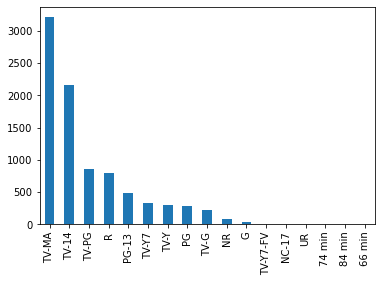

In [28]:
df['Rating'].value_counts().plot(kind='bar')
plt.show()

#### Content Type

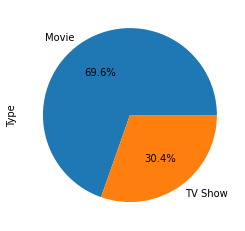

In [29]:
df['Type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.show()

#### Feature Engineering

In [30]:
from sklearn.preprocessing import LabelEncoder

# Create separate encoders
le_country = LabelEncoder()
le_rating = LabelEncoder()
le_type = LabelEncoder()

# Encode columns
df['Country'] = le_country.fit_transform(df['Country'].astype(str))
df['Rating'] = le_rating.fit_transform(df['Rating'].astype(str))
df['Type'] = le_type.fit_transform(df['Type'])

#### Drop Uncessary column

In [31]:
df = df.drop(columns=[
    'Show_ID',
    'Director',
    'Cast',
    'Title',
    'Description',
    'Date_added',
    'Duration'
], errors='ignore')

#### Select features

In [32]:
y = df['Type']

In [33]:
x = df.drop('Type',axis=1)

#### Train-Test Split

In [34]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

### Train multiple models

#### 1. Logistic Regression

In [35]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

#### Decision Tree Classifier

In [36]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()

dt.fit(x_train, y_train)

DecisionTreeClassifier()

#### Random Forest Classifier

In [37]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42,class_weight='balanced')

rf.fit(x_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

#### KNN

In [38]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(x_train, y_train)

KNeighborsClassifier()

#### Navie Bays

In [39]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(x_train, y_train)

GaussianNB()

#### XGBoost

In [40]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [41]:
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42)

xgb.fit(x_train, y_train)

pred = xgb.predict(x_test)

### Make predictions

In [42]:
pred = xgb.predict(x_test)

### Evaluate the models

In [43]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print(accuracy_score(y_test,pred))

print(confusion_matrix(y_test,pred))

print(classification_report(y_test,pred))

0.7542565266742338
[[1055  159]
 [ 274  274]]
              precision    recall  f1-score   support

           0       0.79      0.87      0.83      1214
           1       0.63      0.50      0.56       548

    accuracy                           0.75      1762
   macro avg       0.71      0.68      0.69      1762
weighted avg       0.74      0.75      0.75      1762



#### Compare all models

In [44]:
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "XGBoost": XGBClassifier()
}

results = []

for name, model in models.items():
    model.fit(x_train, y_train)
    pred = model.predict(x_test)
    acc = accuracy_score(y_test, pred)
    results.append([name, acc])

import pandas as pd

result_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
print(result_df.sort_values(by="Accuracy", ascending=False))

                 Model  Accuracy
5              XGBoost  0.754257
2        Random Forest  0.741771
1        Decision Tree  0.740636
3                  KNN  0.729852
0  Logistic Regression  0.694098
4          Naive Bayes  0.619183


#### Visual Model Accuracy

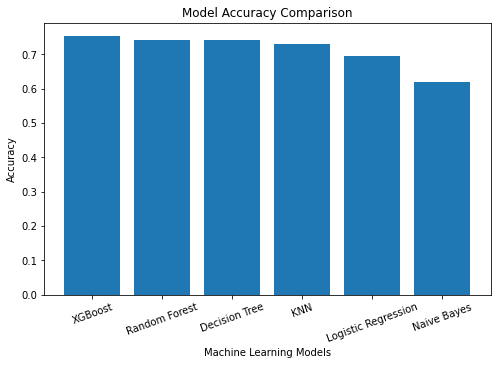

In [45]:
import matplotlib.pyplot as plt

result_df = result_df.sort_values(by="Accuracy", ascending=False)

plt.figure(figsize=(8,5))
plt.bar(result_df["Model"], result_df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.show()

#### Save the best model

In [50]:
import joblib

joblib.dump(xgb,"netflix_model.pkl")

['netflix_model.pkl']

### Build a Dashboard

##### Install Streamlit

In [47]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [48]:
print(x.columns)

Index(['Country', 'Release_Year', 'Rating'], dtype='object')


In [49]:
import joblib

model = joblib.load("netflix_model.pkl")

print(model.n_features_in_)

3
